# READ JPG

In [1]:
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from glob import glob

In [8]:
source2_dir = os.path.abspath("data/raw/source2/A dataset for microscopic peripheral blood cell images for development of automatic recognition systems/PBC_dataset_normal_DIB")
cell_type = "lymphocyte"
img = "LY_3530.jpg"
lymphocyte_dir = os.path.join(source2_dir, cell_type)
image_path = os.path.join(lymphocyte_dir, img)


# Extract RGB pixels image

In [9]:
def extract_pixel_data(image_path):
    # Ouvrir l'image avec PIL
    img = Image.open(image_path)
    
    # Convertir en mode RGB si nécessaire (pour les images en niveaux de gris)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Récupérer les dimensions de l'image
    width, height = img.size
    
    # Extraire les données des pixels
    pixels = list(img.getdata())
    
    # Créer une liste de dictionnaires avec les coordonnées et les valeurs RGB
    pixel_list = []
    for index, pixel in enumerate(pixels):
        x = index % width
        y = index // width
        pixel_list.append({
            'x': x,
            'y': y,
            'red': pixel[0],
            'green': pixel[1],
            'blue': pixel[2]
        })
    
    # Créer le DataFrame
    df = pd.DataFrame(pixel_list)
    return df

# Exemple d'utilisation
pixel_df = extract_pixel_data(image_path)

# Afficher les premières lignes du DataFrame
print(pixel_df.head())

   x  y  red  green  blue
0  0  0  251    223   201
1  1  0  250    222   200
2  2  0  250    222   200
3  3  0  249    221   199
4  4  0  249    221   199


# Visualisation des distributions RGB par type de cellule

In [3]:
def plot_rgb_histograms_by_cell_type(base_dir):
    """
    Crée une figure avec une ligne d'histogrammes RGB pour chaque type de cellule.
    Chaque ligne correspond à un type de cellule et comporte trois sous-graphiques pour les canaux Rouge, Vert et Bleu.

    Args:
        base_dir (str): Chemin vers le répertoire principal contenant les sous-dossiers des types de cellules
    """
    cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    channels = ['red', 'green', 'blue']
    colors = ['red', 'green', 'blue']
    
    # Définir le nombre de lignes en fonction des types de cellules
    n_rows = len(cell_types)
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
    
    # S'assurer que axes est 2D même s'il n'y a qu'une ligne
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for row, cell_type in enumerate(cell_types):
        cell_dir = os.path.join(base_dir, cell_type)
        if not os.path.exists(cell_dir):
            print(f"Le dossier pour '{cell_type}' n'existe pas.")
            continue
        
        # Initialiser un dictionnaire pour stocker les données par canal
        data = {ch: [] for ch in channels}
        image_files = glob(os.path.join(cell_dir, "*.jpg"))
        
        # Parcourir un nombre limité d'images
        for img_path in image_files[:30]:
            df = extract_pixel_data(img_path)
            for ch in channels:
                data[ch].extend(df[ch])
        
        # Pour chaque canal, tracer un histogramme
        for col, ch in enumerate(channels):
            # Calculer les statistiques
            mean_val = np.mean(data[ch]) if len(data[ch]) > 0 else 0
            std_val = np.std(data[ch]) if len(data[ch]) > 0 else 0
            
            sns.histplot(data[ch], bins=50, color=colors[col], alpha=0.6, ax=axes[row, col])
            axes[row, col].set_title(f"{cell_type.capitalize()} - {ch.capitalize()} (μ={mean_val:.1f}, σ={std_val:.1f})")
            axes[row, col].set_xlabel("Valeur")
            axes[row, col].set_ylabel("Fréquence")
    
    plt.tight_layout()
    plt.show()

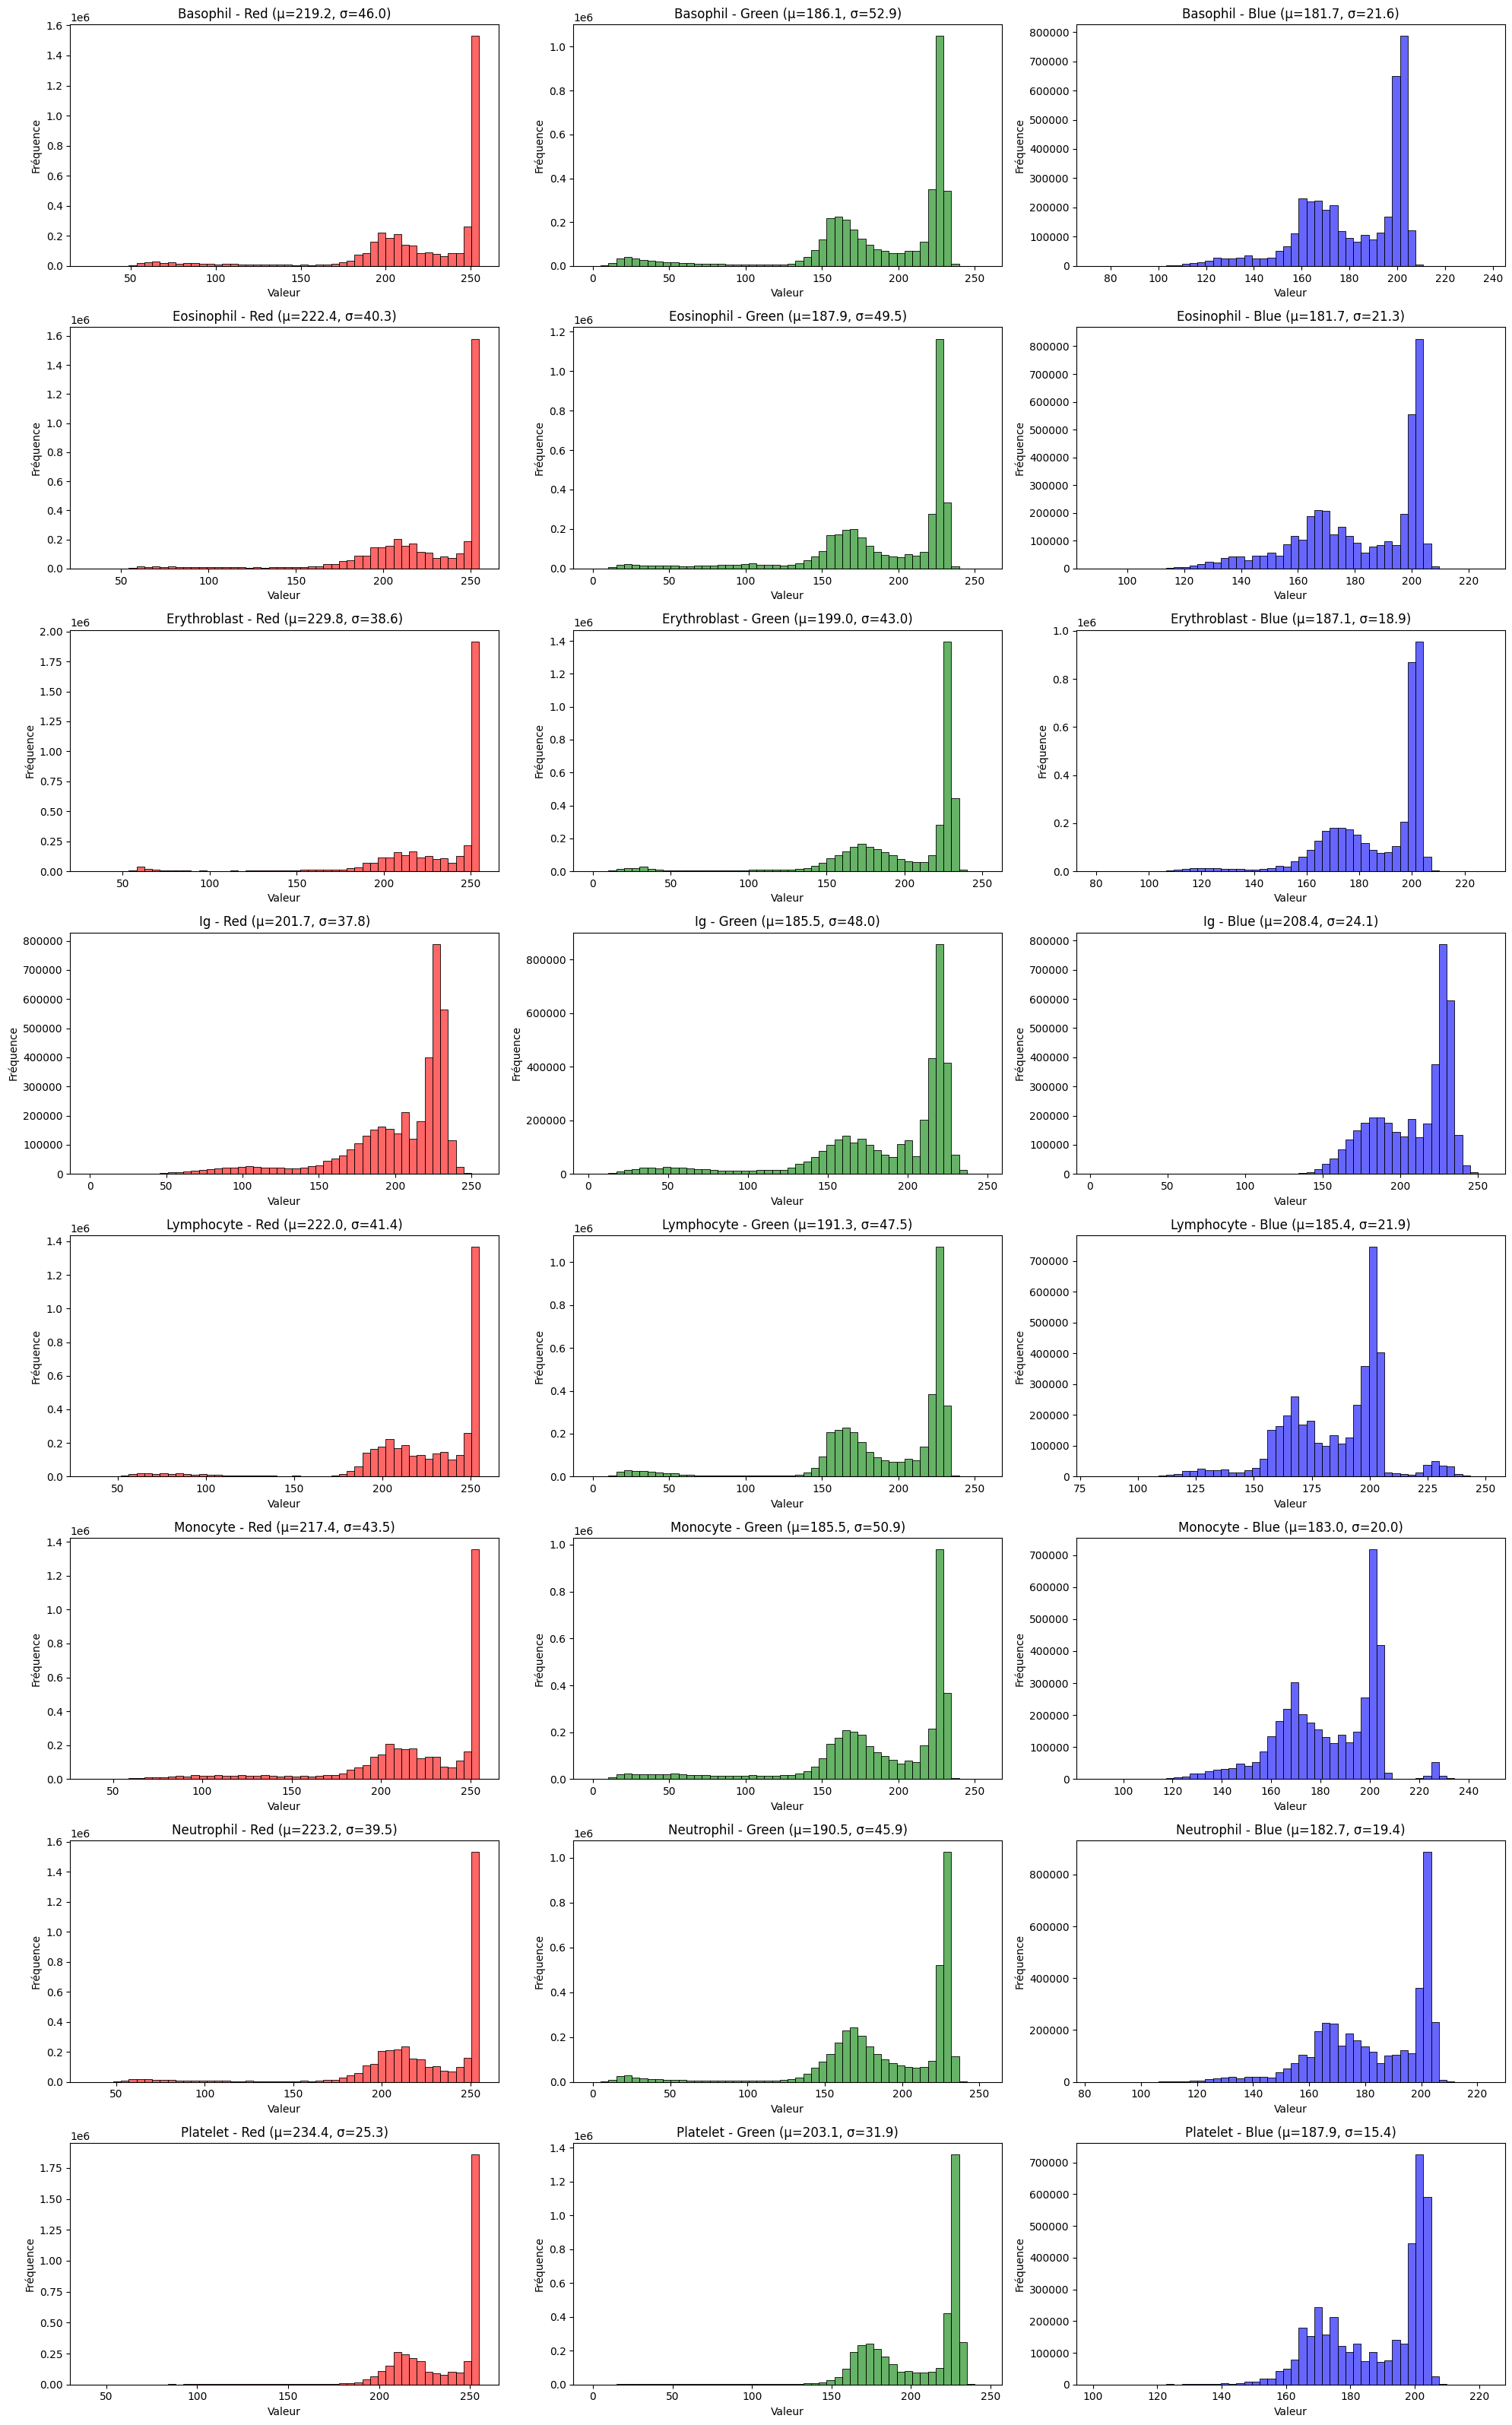

In [6]:
plot_rgb_histograms_by_cell_type(source2_dir)

# Visualisation des distributions RGB sur la meme figure

In [4]:
def visualize_cell_types_distribution(base_dir):
    """
    Crée une visualisation claire des distributions RGB pour chaque type de cellule.
    
    Args:
        base_dir (str): Chemin vers le répertoire principal contenant les sous-dossiers des types de cellules
    """
    cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                  'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
    # Créer une grille de sous-graphiques (4x2)
    fig, axes = plt.subplots(4, 2, figsize=(20, 24))
    fig.suptitle('Distribution RGB par type de cellule', fontsize=16, y=0.95)
    axes = axes.ravel()  # Aplatir le tableau d'axes pour un accès plus facile
    
    # Couleurs pour les canaux RGB avec une meilleure transparence
    colors = ['#FF000080', '#00FF0080', '#0000FF80']
    labels = ['Rouge', 'Vert', 'Bleu']
    
    for idx, cell_type in enumerate(cell_types):
        cell_dir = os.path.join(base_dir, cell_type)
        if not os.path.exists(cell_dir):
            print(f"Dossier non trouvé pour {cell_type}")
            continue
            
        # Récupérer les données RGB
        all_red, all_green, all_blue = [], [], []
        image_files = glob(os.path.join(cell_dir, "*.jpg"))
        
        for img_path in image_files[:30]:
            df = extract_pixel_data(img_path)
            all_red.extend(df['red'])
            all_green.extend(df['green'])
            all_blue.extend(df['blue'])
        
        # Échantillonnage pour améliorer les performances
        sample_size = min(10000, len(all_red))
        indices = np.random.choice(len(all_red), sample_size, replace=False)
        
        rgb_data = [
            np.array(all_red)[indices],
            np.array(all_green)[indices],
            np.array(all_blue)[indices]
        ]
        
        # Tracer les courbes de densité
        for color_data, color, label in zip(rgb_data, colors, labels):
            sns.kdeplot(
                data=color_data,
                ax=axes[idx],
                color=color,
                label=label,
                fill=True,
                alpha=0.3,
                linewidth=2
            )
        
        axes[idx].set_title(f'Type: {cell_type}')
        axes[idx].set_xlabel('Valeur de pixel')
        axes[idx].set_ylabel('Densité')
        axes[idx].legend()
        
        # Ajouter des statistiques dans le titre
        stats_text = f'μ(R)={np.mean(rgb_data[0]):.1f}, μ(G)={np.mean(rgb_data[1]):.1f}, μ(B)={np.mean(rgb_data[2]):.1f}'
        axes[idx].set_title(f'Type: {cell_type}\n{stats_text}', pad=10)
    
    plt.tight_layout()
    plt.show()

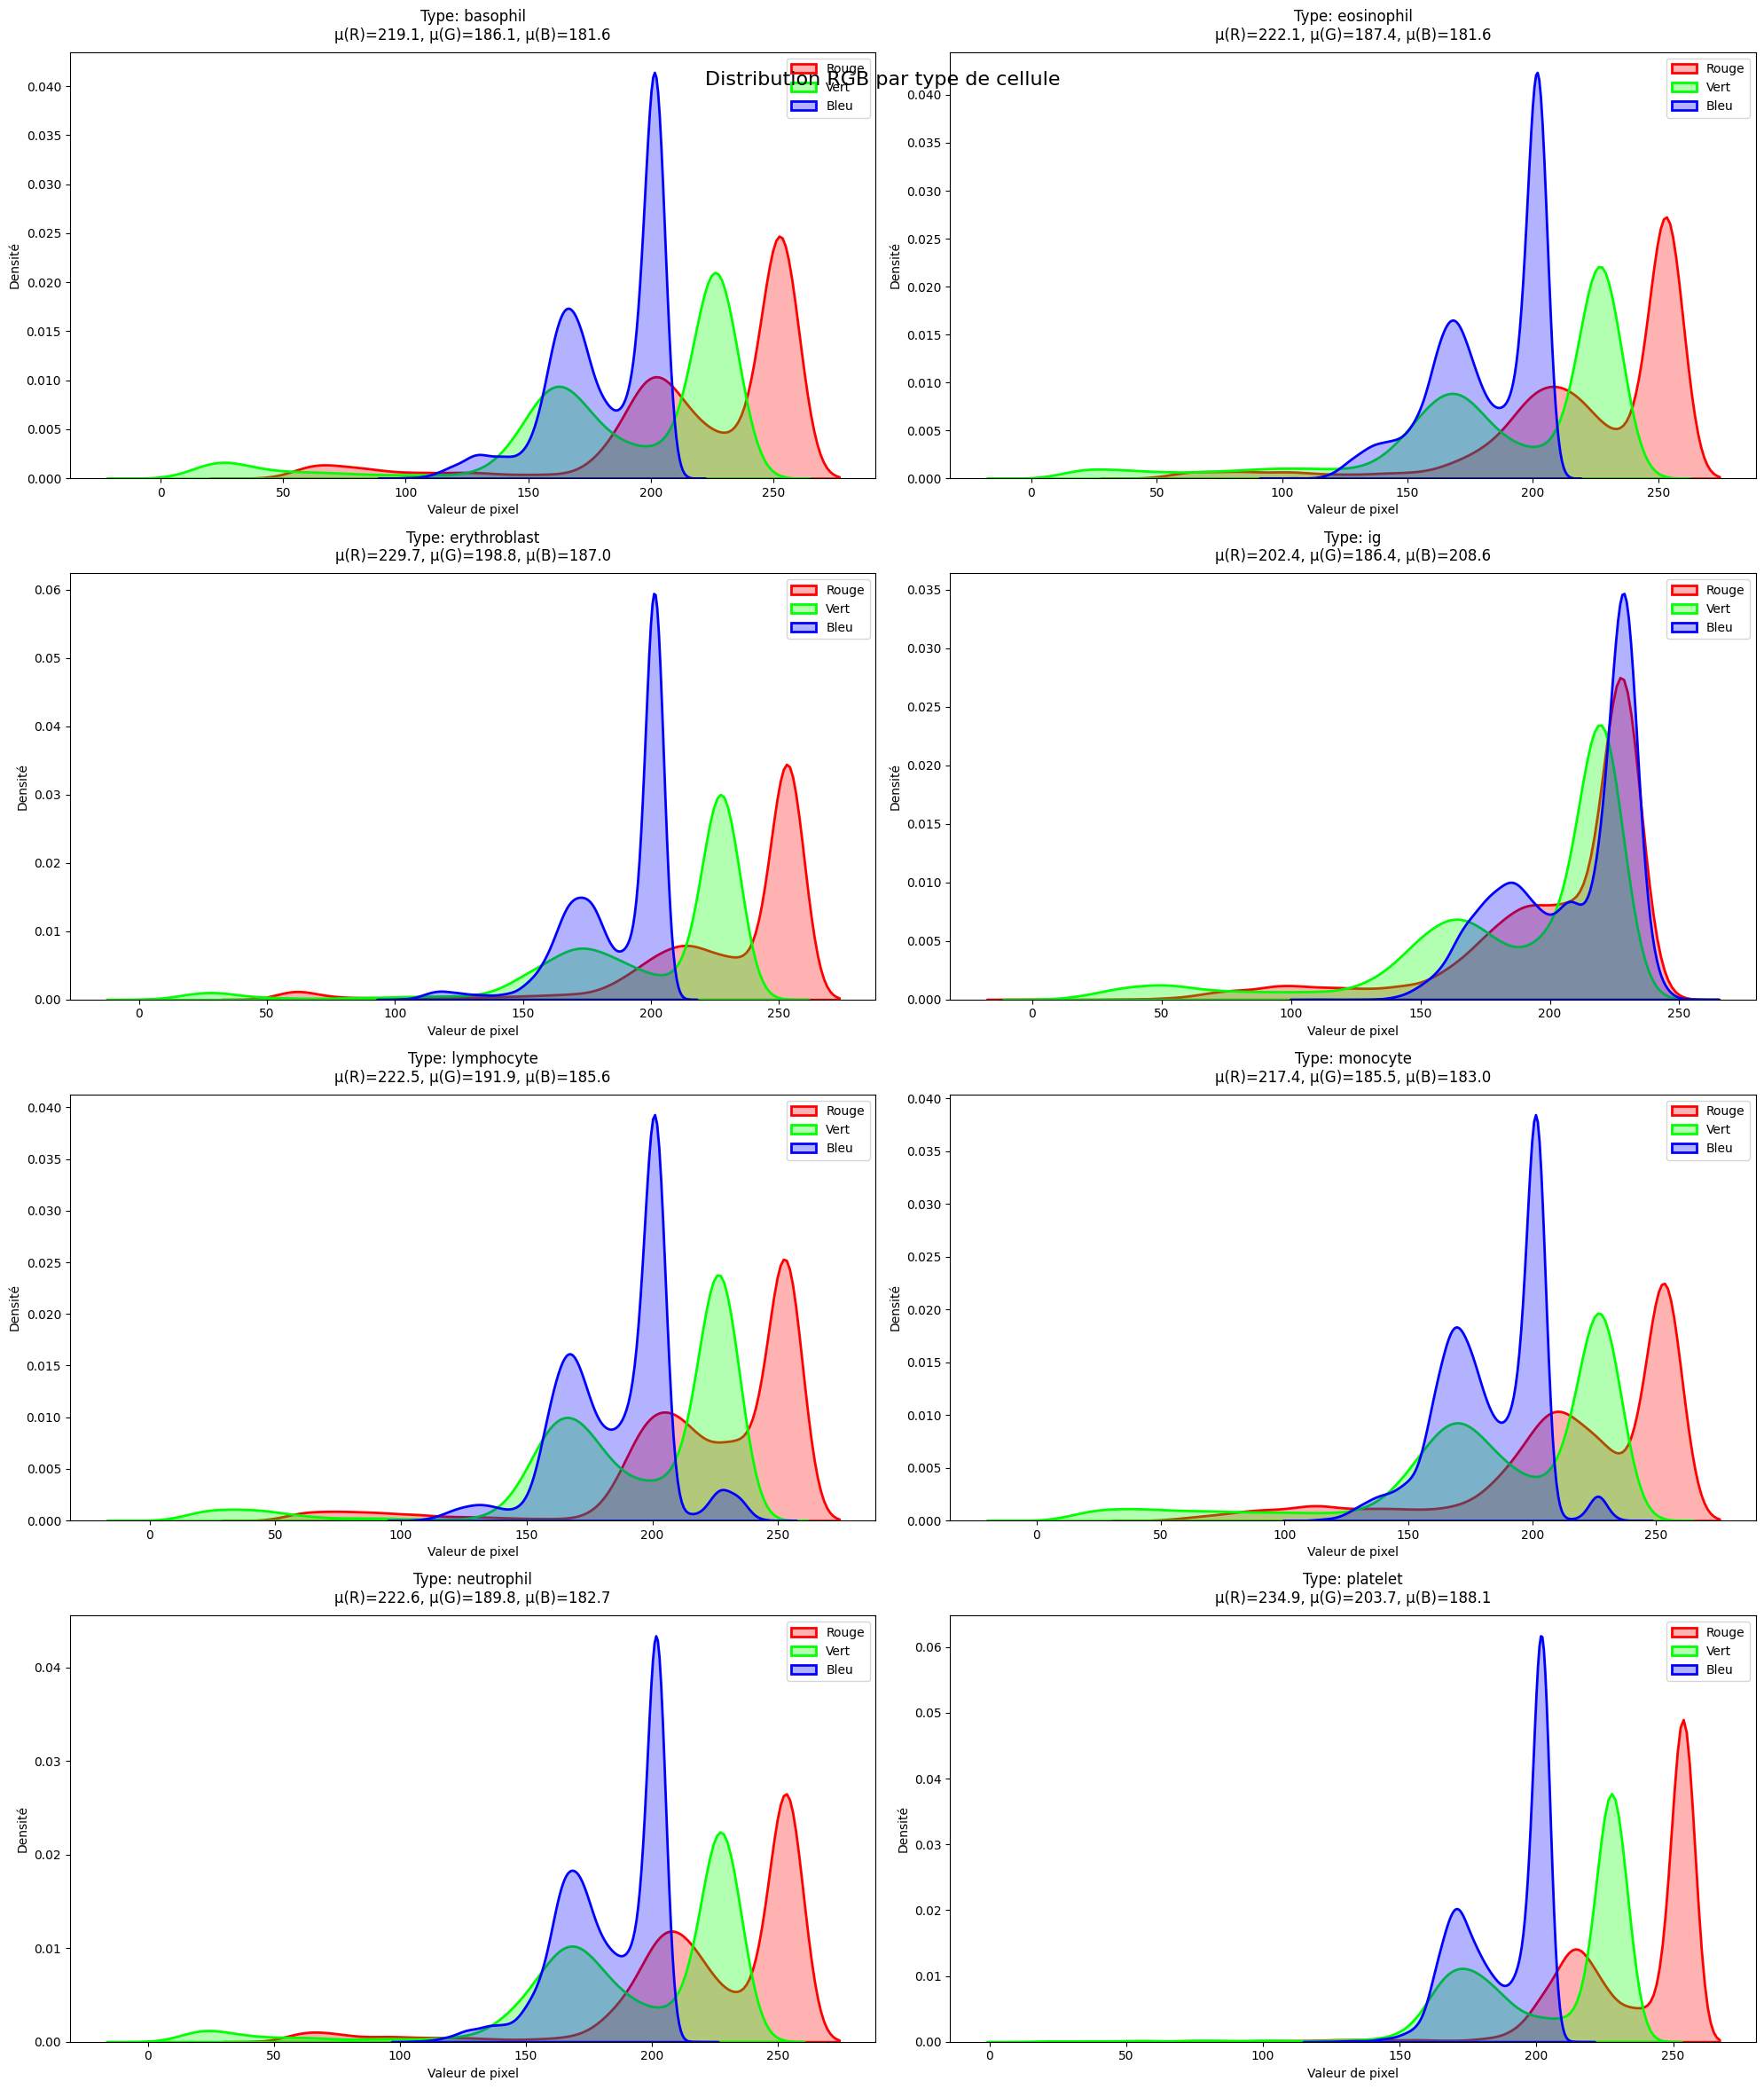

In [6]:
visualize_cell_types_distribution(source2_dir)

# Visualisation des distributions RGB pour une seule cellule

In [ ]:
def visualize_rgb_distribution(directory_path, cell_type=None, axes=None):
    """
    Visualise la distribution des canaux RGB pour toutes les images d'un type de cellule donné.
    
    Args:
        directory_path (str): Chemin vers le répertoire contenant les images
        cell_type (str): Nom du type de cellule (pour le titre)
        axes (tuple): Tuple de 3 axes matplotlib pour le tracé (optionnel)
    """
    # Récupérer toutes les images du répertoire
    image_files = glob(os.path.join(directory_path, "*.jpg"))
    
    # Initialiser les listes pour stocker les valeurs RGB
    all_red = []
    all_green = []
    all_blue = []
    
    # Analyser chaque image
    for img_path in image_files[:30]:
        df = extract_pixel_data(img_path)
        all_red.extend(df['red'])
        all_green.extend(df['green'])
        all_blue.extend(df['blue'])
    
    # Si axes n'est pas fourni, créer une nouvelle figure
    if axes is None:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f'Distribution RGB pour {cell_type if cell_type else "les cellules"}', fontsize=14)
    else:
        ax1, ax2, ax3 = axes
    
    # Tracer les histogrammes
    sns.histplot(all_red, color='red', alpha=0.3, bins=50, ax=ax1, label=cell_type)
    ax1.set_title('Canal Rouge')
    ax1.set_xlabel('Valeur')
    ax1.set_ylabel('Fréquence')
    
    sns.histplot(all_green, color='green', alpha=0.3, bins=50, ax=ax2, label=cell_type)
    ax2.set_title('Canal Vert')
    ax2.set_xlabel('Valeur')
    ax2.set_ylabel('Fréquence')
    
    sns.histplot(all_blue, color='blue', alpha=0.3, bins=50, ax=ax3, label=cell_type)
    ax3.set_title('Canal Bleu')
    ax3.set_xlabel('Valeur')
    ax3.set_ylabel('Fréquence')
    
    # Ajouter les légendes
    for ax in [ax1, ax2, ax3]:
        ax.legend()
    
    if axes is None:
        plt.tight_layout()
        plt.show()
    
    # Afficher quelques statistiques
    print(f"\nStatistiques pour {cell_type if cell_type else 'les cellules'}:")
    print(f"Rouge - Moyenne: {np.mean(all_red):.2f}, Écart-type: {np.std(all_red):.2f}")
    print(f"Vert  - Moyenne: {np.mean(all_green):.2f}, Écart-type: {np.std(all_green):.2f}")
    print(f"Bleu  - Moyenne: {np.mean(all_blue):.2f}, Écart-type: {np.std(all_blue):.2f}")
